# 01 - Dataset Verification & Exploratory Data Analysis

**Owner:** Member 1

## Objectives
1. Verify dataset provenance (source, creator, licence, version) and the actual file counts.
2. Describe the class and split distributions.
3. Inspect image properties (resolution, aspect ratio, file format, file size).
4. Detect corrupt/unreadable files.
5. Detect exact and near-duplicate images, **especially across Train / Validation / Test** (data leakage).
6. Characterise pixel-level statistics (colour, brightness, contrast, sharpness) per class and per split.
7. Record the implications of each finding for preprocessing, training and evaluation.

All findings below are computed from the downloaded files; nothing is copied from secondary sources.

## 1. Setup

In [1]:
import hashlib, json, os, platform
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageStat

DATASET_DIR = Path("../dataset")
SPLITS = ["Train", "Validation", "Test"]
CLASS_NAMES = ["Healthy", "Powdery", "Rust"]
FIG_DIR = Path("../figures/eda"); FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("../results"); RESULTS_DIR.mkdir(exist_ok=True)
SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"Healthy": "#2e7d32", "Powdery": "#9e9e9e", "Rust": "#c75b12"}

## 2. Dataset provenance
Metadata retrieved from the Kaggle public API (`/api/v1/datasets/view/rashikrahmanpritom/plant-disease-recognition-dataset`) on 27 Sep 2026 and saved to `results/dataset_metadata.json`.

| Field | Value |
|---|---|
| Title | Plant disease recognition dataset |
| Kaggle URL | https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset |
| Creator / owner | Rashik Rahman (`rashikrahmanpritom`) |
| Licence | CC0: Public Domain (CC0-1.0) |
| Version | 1 (last updated 2021-07-04) |
| Stated source | "Online" (no further provenance given by the creator) |
| Creator's description | Three labels, "Healthy", "Powdery", "Rust"; "a total of 1530 images divided into train, test, and validation sets" |
| Download size | 1.35 GB (archive) |
| Download method | `kagglehub.dataset_download(...)`; the archive nests each split twice (`Train/Train/<class>`), flattened to `dataset/<split>/<class>` |

In [2]:
metadata = {
    "title": "Plant disease recognition dataset",
    "url": "https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset",
    "kaggle_ref": "rashikrahmanpritom/plant-disease-recognition-dataset",
    "creator": "Rashik Rahman", "owner_ref": "rashikrahmanpritom",
    "license": "CC0: Public Domain (CC0-1.0)", "version": 1, "last_updated": "2021-07-04",
    "user_specified_sources": "Online",
    "stated_total_images": 1530, "archive_bytes": 1353240862,
    "retrieved_on": "2026-09-27",
}
with open(RESULTS_DIR / "dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

## 3. File inventory and class distribution

In [3]:
records = []
for split in SPLITS:
    for cls in CLASS_NAMES:
        for p in sorted((DATASET_DIR / split / cls).iterdir()):
            records.append({"split": split, "class": cls, "path": p, "filename": p.name,
                            "extension": p.suffix.lower(), "file_kb": p.stat().st_size / 1024})
df = pd.DataFrame(records)
counts = df.pivot_table(index="class", columns="split", values="filename", aggfunc="count")[SPLITS]
counts.loc["Total"] = counts.sum()
counts["All splits"] = counts.sum(axis=1)
print("Total files:", len(df), "| extensions:", dict(Counter(df.extension)))
print("Creator-stated total: 1530 -> difference:", len(df) - 1530)
counts

Total files: 1532 | extensions: {'.jpg': 1532}
Creator-stated total: 1530 -> difference: 2


split,Train,Validation,Test,All splits
class,,,,
Healthy,458,20,50,528
Powdery,430,20,50,500
Rust,434,20,50,504
Total,1322,60,150,1532


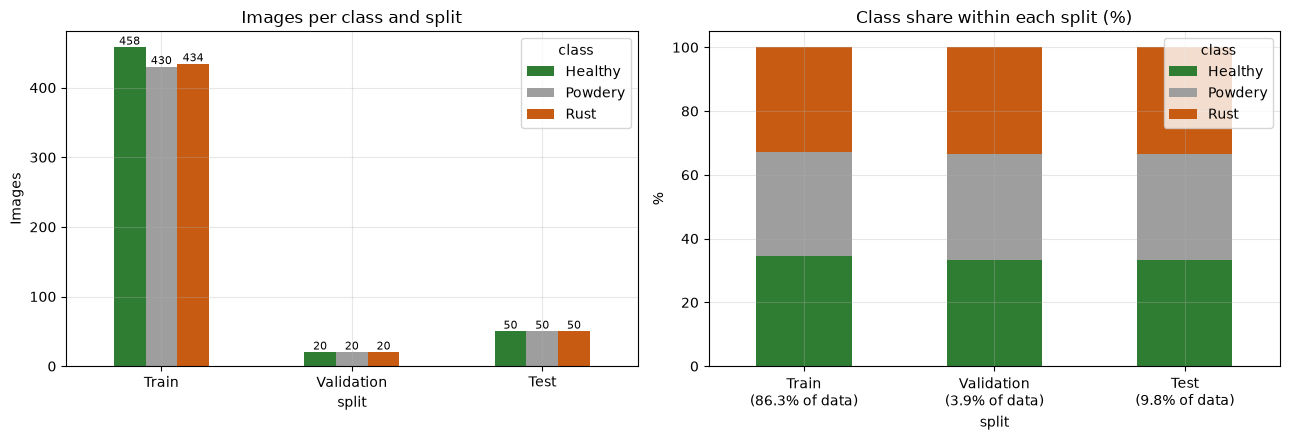

Train imbalance ratio (max/min): 1.065
Split proportions (%): {'Train': 86.29, 'Validation': 3.92, 'Test': 9.79}


In [4]:
share = df.groupby(["split", "class"]).size().unstack()[CLASS_NAMES].loc[SPLITS]
pct = share.div(share.sum(axis=1), axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
share.plot(kind="bar", ax=axes[0], color=[COLORS[c] for c in CLASS_NAMES], rot=0)
axes[0].set(title="Images per class and split", ylabel="Images")
for cont in axes[0].containers: axes[0].bar_label(cont, fontsize=8)
pct.plot(kind="bar", stacked=True, ax=axes[1], color=[COLORS[c] for c in CLASS_NAMES], rot=0)
axes[1].set(title="Class share within each split (%)", ylabel="%")
split_share = df.split.value_counts(normalize=True)[SPLITS] * 100
axes[1].set_xticklabels([f"{s}\n({split_share[s]:.1f}% of data)" for s in SPLITS])
plt.tight_layout(); plt.savefig(FIG_DIR / "class_distribution.png", dpi=200, bbox_inches="tight"); plt.show()

train_counts = share.loc["Train"]
print("Train imbalance ratio (max/min):", round(train_counts.max() / train_counts.min(), 3))
print("Split proportions (%):", split_share.round(2).to_dict())

**Interpretation.** The dataset contains **1,532 JPEG files**, two more than the 1,530 stated by the creator; the local files were not altered to force agreement and the discrepancy is recorded. The training set is **almost balanced** (Healthy 458, Powdery 430, Rust 434; max/min ratio 1.065), and Validation (20/20/20) and Test (50/50/50) are perfectly balanced. Consequences: (1) accuracy is a meaningful headline metric and no class weighting or resampling is required; (2) weighted and macro averages of precision/recall/F1 will be almost identical. The split proportions are unusual: **86.3% train / 3.9% validation / 9.8% test**. With only 60 validation images, one image changes validation accuracy by 1.67 percentage points, so validation accuracy saturates quickly (both fine-tuned transfer models reached 100%) and cannot separate strong configurations. Validation **loss** is therefore the more informative selection signal, and this limitation must be acknowledged when discussing hyperparameter tuning. The provided splits are kept unchanged so all four models share one protocol.

## 4. Representative images

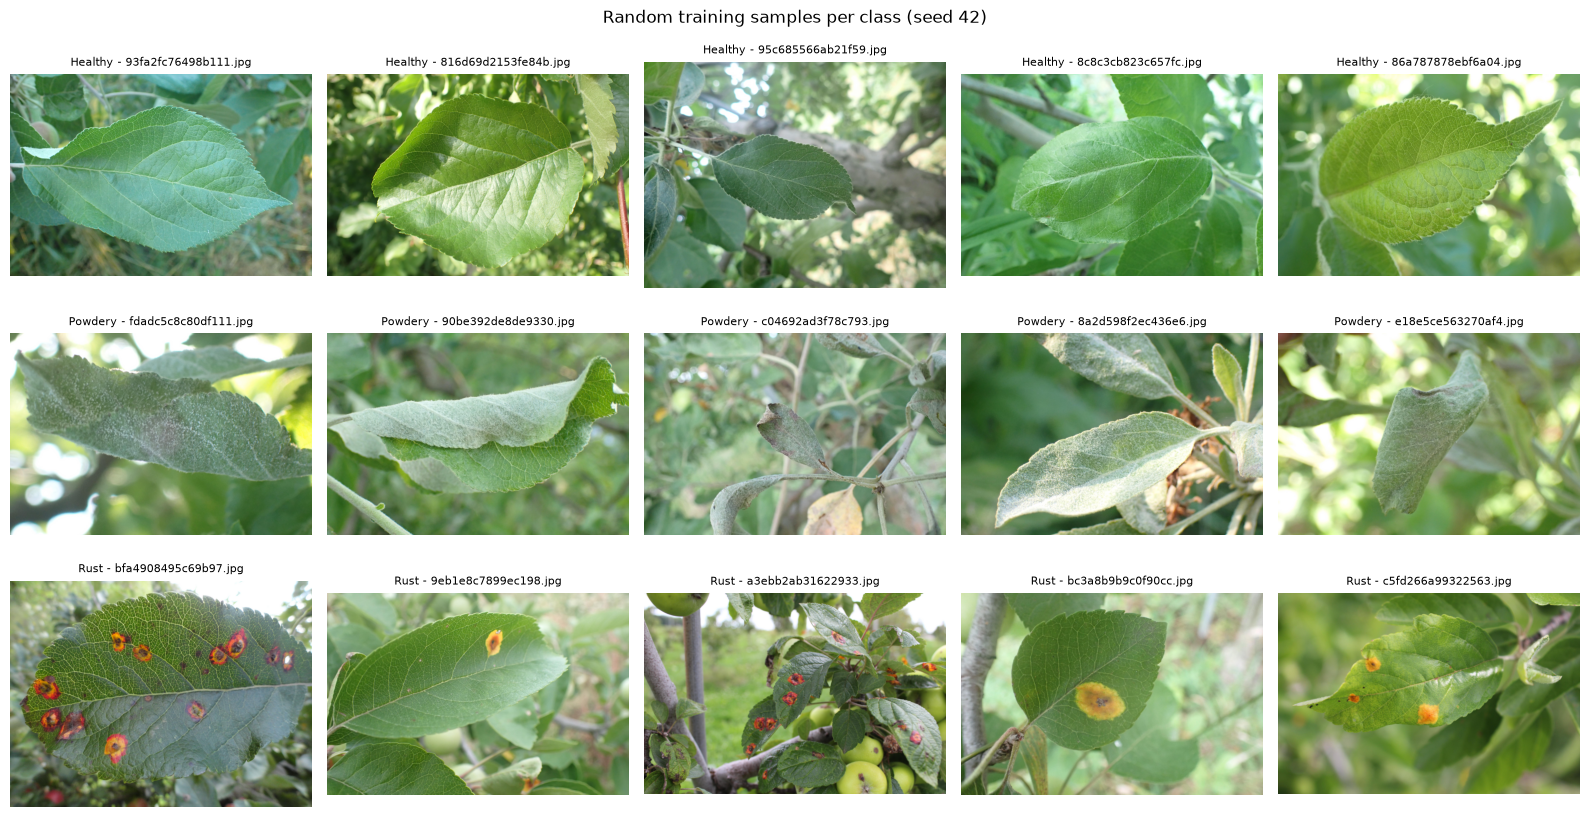

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8.5))
for r, cls in enumerate(CLASS_NAMES):
    sample = df[(df.split == "Train") & (df["class"] == cls)].sample(5, random_state=SEED)
    for c, (_, row) in enumerate(sample.iterrows()):
        im = Image.open(row.path); im.draft("RGB", (600, 400))
        axes[r, c].imshow(im.convert("RGB")); axes[r, c].axis("off")
        axes[r, c].set_title(f"{cls} - {row.filename}", fontsize=8)
plt.suptitle("Random training samples per class (seed 42)"); plt.tight_layout()
plt.savefig(FIG_DIR / "sample_grid.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation.** Images are **in-field photographs** of apple-type leaves on the tree rather than lab images on a uniform background (unlike PlantVillage). Each frame contains a dominant target leaf, but also neighbouring leaves, branches, fruit, sky and soil, with variable natural lighting and depth of field. Class cues differ in scale: **Rust** produces discrete orange/red lesions that can be small relative to the leaf, **Powdery** appears as a diffuse whitish-grey coating that changes leaf texture and colour globally, and **Healthy** leaves are uniformly green. Implications: models must learn to focus on the target leaf in cluttered scenes; small rust spots may be lost when a ~4000×2672 image is down-sampled to 224×224; and the whitish Powdery coating can resemble specular glare or over-exposed healthy leaves, a plausible source of Healthy↔Powdery confusion.

## 5. Image properties, corrupt-file check and pixel statistics
For every file: header metadata (format, mode, width, height, EXIF orientation), a full decode to detect corruption, MD5 hash (exact duplicates), a 64-bit difference hash (near-duplicates), and pixel statistics on a down-sampled copy (mean R/G/B, brightness, contrast, sharpness = variance of a Laplacian-style edge filter, fraction of green-dominant pixels as a rough "leaf coverage" proxy).

In [6]:
def dhash(im, size=8):
    g = im.convert("L").resize((size + 1, size), Image.Resampling.LANCZOS)
    a = np.asarray(g, dtype=np.int16)
    bits = (a[:, 1:] > a[:, :-1]).flatten()
    return int("".join("1" if b else "0" for b in bits), 2)

def inspect(path):
    out = {"readable": True, "error": ""}
    try:
        with Image.open(path) as im:
            out.update(format=im.format, mode=im.mode, width=im.width, height=im.height,
                       exif_orientation=im.getexif().get(274, 1))
            im.verify()
        with Image.open(path) as im:
            im.draft("RGB", (im.width // 8, im.height // 8))
            small = im.convert("RGB")
            small.thumbnail((256, 256))
        arr = np.asarray(small, dtype=np.float32)
        gray = small.convert("L")
        edges = np.asarray(gray.filter(ImageFilter.FIND_EDGES), dtype=np.float32)
        r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
        out.update(mean_r=r.mean(), mean_g=g.mean(), mean_b=b.mean(),
                   brightness=np.asarray(gray, dtype=np.float32).mean(),
                   contrast=np.asarray(gray, dtype=np.float32).std(),
                   sharpness=edges.var(),
                   green_fraction=float(((g > r) & (g > b)).mean()),
                   dhash=dhash(small))
        out["md5"] = hashlib.md5(path.read_bytes()).hexdigest()
    except Exception as e:
        out.update(readable=False, error=repr(e))
    return out

props = pd.DataFrame([inspect(p) for p in df.path])
df = pd.concat([df.reset_index(drop=True), props], axis=1)
df["aspect_ratio"] = df.width / df.height
df["megapixels"] = df.width * df.height / 1e6
print("Unreadable / corrupt files:", int((~df.readable).sum()))
print("Formats:", dict(Counter(df.format)), "| modes:", dict(Counter(df["mode"])))
print("EXIF orientation values:", dict(Counter(df.exif_orientation)))
df.drop(columns=["path"]).to_csv(RESULTS_DIR / "eda_image_properties.csv", index=False)

Unreadable / corrupt files: 0
Formats: {'JPEG': 1532} | modes: {'RGB': 1532}
EXIF orientation values: {1: 1532}


**Interpretation.** All 1,532 files decode successfully (**0 corrupt/unreadable files**), all are 3-channel RGB JPEGs, and no file carries a non-default EXIF orientation tag, so no image will be silently rotated during loading. No cleaning or format conversion is required before training.

### 5.1 Resolution and aspect ratio

Distinct resolutions: 8


,width,height,images,orientation
0,4000,2672,1130,landscape
1,2592,1728,127,landscape
2,5184,3456,97,landscape
3,4000,3000,88,landscape
4,4608,3456,72,landscape
5,4032,3024,16,landscape
6,3901,2607,1,landscape
7,2421,2279,1,landscape


split                  Test    Train  Validation
width        count   150.00  1322.00       60.00
             mean   3938.97  3989.75     4022.40
             std     573.58   513.83      558.01
             min    2592.00  2421.00     2592.00
             25%    4000.00  4000.00     4000.00
             50%    4000.00  4000.00     4000.00
             75%    4000.00  4000.00     4000.00
             max    5184.00  5184.00     5184.00
height       count   150.00  1322.00       60.00
             mean   2656.10  2706.56     2727.73
             std     409.46   380.98      414.57
             min    1728.00  1728.00     1728.00
             25%    2672.00  2672.00     2672.00
             50%    2672.00  2672.00     2672.00
             75%    2672.00  2672.00     2672.00
             max    3456.00  3456.00     3456.00
megapixels   count   150.00  1322.00       60.00
             mean     10.69    10.99       11.19
             std       2.98     2.77        3.06
             min    

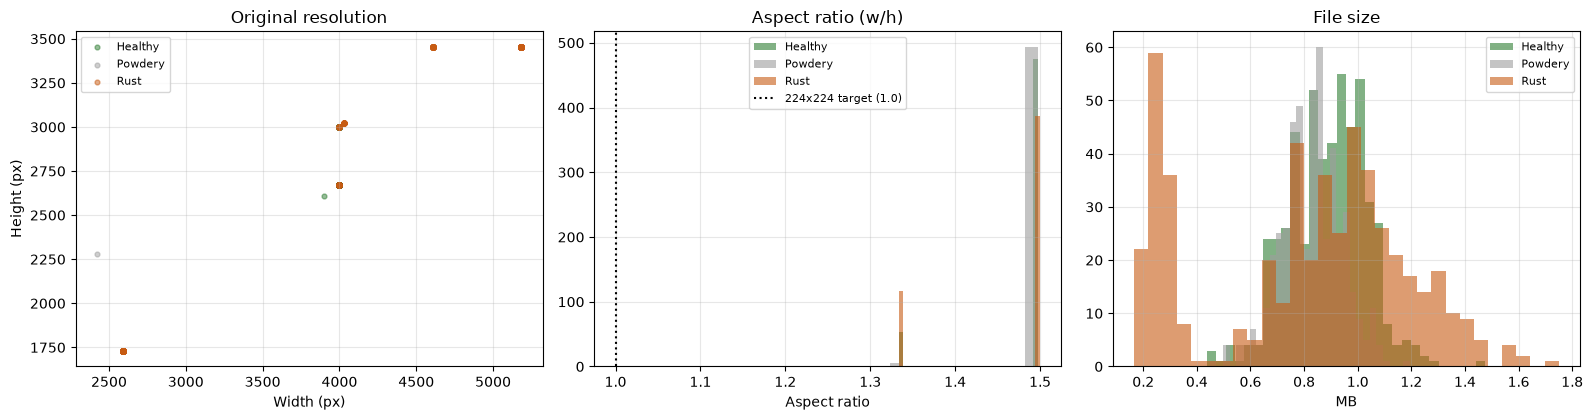

In [7]:
res = df.groupby(["width", "height"]).size().sort_values(ascending=False).rename("images").reset_index()
res["orientation"] = np.where(res.width >= res.height, "landscape", "portrait")
print("Distinct resolutions:", len(res))
display(res.head(10))
print(df.groupby("split")[["width", "height", "megapixels", "aspect_ratio", "file_kb"]].describe().T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for cls in CLASS_NAMES:
    d = df[df["class"] == cls]
    axes[0].scatter(d.width, d.height, s=12, alpha=0.5, label=cls, color=COLORS[cls])
    axes[1].hist(d.aspect_ratio, bins=30, alpha=0.6, label=cls, color=COLORS[cls])
    axes[2].hist(d.file_kb / 1024, bins=30, alpha=0.6, label=cls, color=COLORS[cls])
axes[0].set(title="Original resolution", xlabel="Width (px)", ylabel="Height (px)")
axes[1].set(title="Aspect ratio (w/h)", xlabel="Aspect ratio"); axes[1].axvline(1.0, color="k", ls=":", label="224x224 target (1.0)")
axes[2].set(title="File size", xlabel="MB")
for a in axes: a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "image_dimensions.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation.** Images are **very high resolution** (median 10.7 MP; 1,130 of 1,532 are 4000×2672) with 8 distinct resolutions, all landscape, and an aspect ratio of about **1.5:1** (a few at 1.33 and one at 1.06). The shared pipeline resizes directly to 224×224 without cropping or padding, which **compresses the width by ~33% more than the height** and changes leaf and lesion shapes. Because the distortion is identical for every class, split and model it does not bias the comparison, but it is a documented design decision and a candidate improvement (aspect-preserving resize + padding, or centre-crop). The ~18× linear down-sampling also means fine lesion texture is partly lost, which favours models that exploit colour and larger-scale patterns. Resolution and file-size distributions are very similar across Train, Validation and Test.

### 5.2 Colour, brightness, contrast and sharpness

mean_r             mean_g                 mean_b             \
               mean    std        mean        std        mean        std   
class                                                                      
Healthy  114.059998  14.53  152.520004  13.130000   95.550003  19.059999   
Powdery  128.899994  11.70  154.259995   9.600000  113.589996  11.780000   
Rust     116.860001  20.00  143.229996  20.940001   94.730003  21.320000   

         brightness          contrast           sharpness              \
               mean    std       mean    std         mean         std   
class                                                                   
Healthy  134.529999  11.94  40.540001  11.59  1345.449951  438.779999   
Powdery  142.039993   8.85  38.980000   8.45  1039.699951  316.880005   
Rust     129.820007  19.60  40.599998   8.78  1399.209961  550.460022   

        green_fraction        
                  mean   std  
class                         
Healthy           0.95  0.05  
Powdery           0.92  0.08  
Rust              0.88  0.08

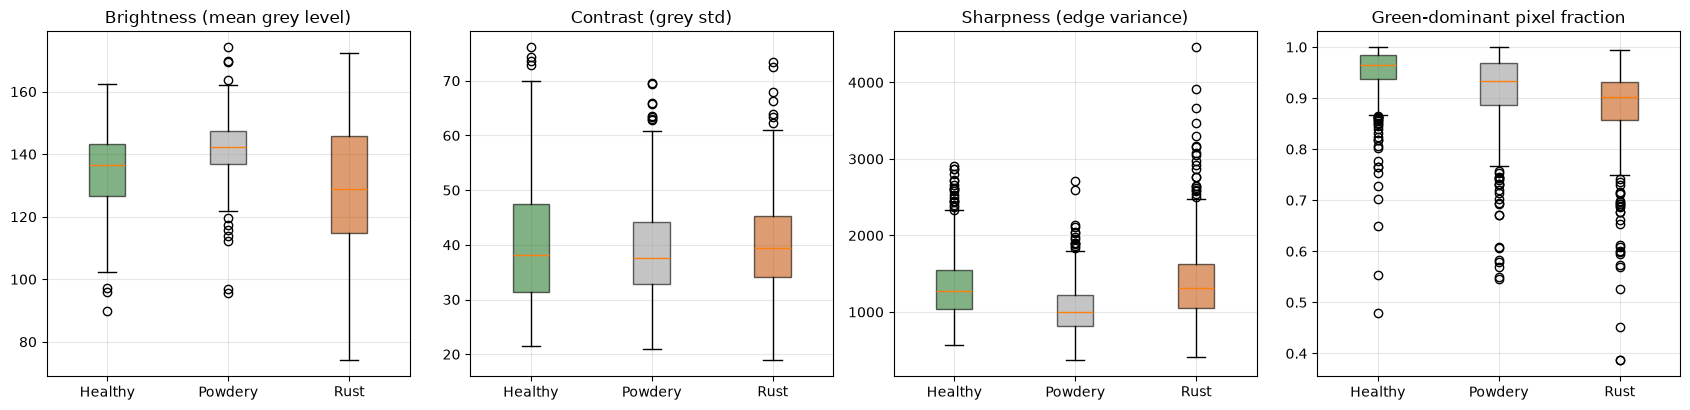

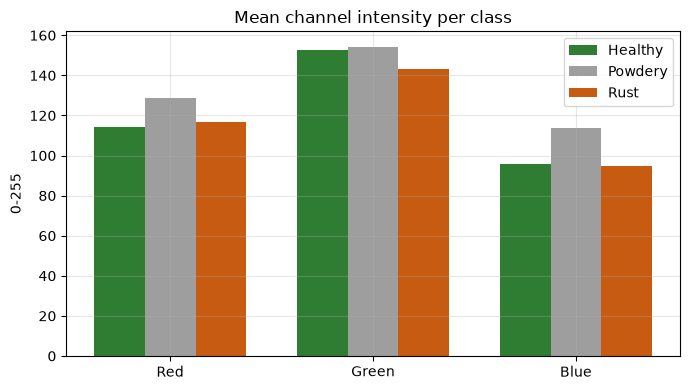

In [8]:
features = ["mean_r", "mean_g", "mean_b", "brightness", "contrast", "sharpness", "green_fraction"]
summary = df.groupby("class")[features].agg(["mean", "std"]).round(2)
display(summary)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, feat, title in zip(axes, ["brightness", "contrast", "sharpness", "green_fraction"],
                           ["Brightness (mean grey level)", "Contrast (grey std)", "Sharpness (edge variance)", "Green-dominant pixel fraction"]):
    ax.boxplot([df.loc[df["class"] == c, feat] for c in CLASS_NAMES], tick_labels=CLASS_NAMES, patch_artist=True,
               boxprops=dict(alpha=0.6))
    for patch, c in zip(ax.patches, CLASS_NAMES): patch.set_facecolor(COLORS[c])
    ax.set_title(title)
plt.tight_layout(); plt.savefig(FIG_DIR / "pixel_statistics_by_class.png", dpi=200, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3); w = 0.25
for i, cls in enumerate(CLASS_NAMES):
    ax.bar(x + (i - 1) * w, df.loc[df["class"] == cls, ["mean_r", "mean_g", "mean_b"]].mean(), w, label=cls, color=COLORS[cls])
ax.set_xticks(x, ["Red", "Green", "Blue"]); ax.set(title="Mean channel intensity per class", ylabel="0-255"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "mean_rgb_by_class.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation.** The classes differ in global colour statistics in a biologically sensible way. **Powdery** images are the brightest (mean grey 142 vs 135 Healthy and 130 Rust), have a higher blue channel (113.6 vs ~95) and the lowest sharpness, consistent with a whitish, low-texture fungal coating. **Healthy** images have the highest green-dominant fraction (0.95), **Rust** the lowest (0.88), consistent with orange lesions. **Rust** is the most variable class in brightness (std 19.6) and includes the darkest images. These differences mean that part of the signal is available as colour, which helps a from-scratch CNN; they also warn that a model could partly rely on global brightness/colour rather than lesion morphology — Grad-CAM and error analysis in the model notebooks are used to check this. Colour-altering augmentation (hue shifts) was therefore deliberately **not** used, because colour is diagnostic.

### 5.3 Do the splits come from the same distribution?

,brightness,contrast,sharpness,green_fraction,megapixels
split,,,,,
Train,135.710007,40.160000,1268.699951,0.92,10.99
Validation,130.630005,38.790001,1241.050049,0.92,11.19
Test,134.899994,39.580002,1225.109985,0.93,10.69


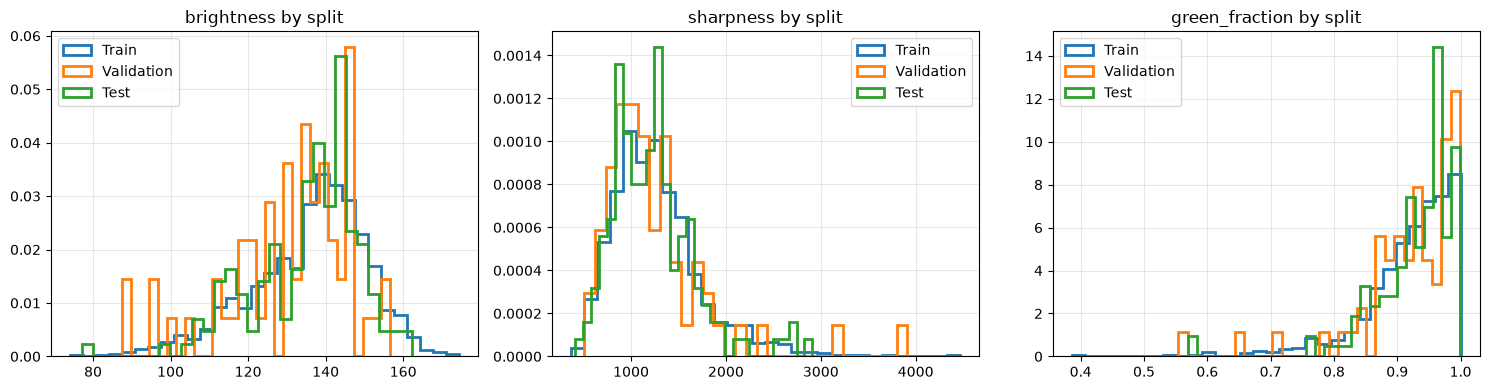

In [9]:
display(df.groupby("split")[["brightness", "contrast", "sharpness", "green_fraction", "megapixels"]].mean().loc[SPLITS].round(2))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ["brightness", "sharpness", "green_fraction"]):
    for s in SPLITS:
        ax.hist(df.loc[df.split == s, feat], bins=30, density=True, histtype="step", lw=2, label=s)
    ax.set_title(f"{feat} by split"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "split_distribution_shift.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation.** Mean brightness, contrast, sharpness, green fraction and resolution are closely matched across Train, Validation and Test (e.g. brightness 135.7 / 130.6 / 134.9), and the histograms overlap. There is no evidence of a covariate shift between splits, so test performance should be a fair estimate of performance **on images from the same source**. It does not measure robustness to other cameras, crops, regions or growth stages.

### 5.4 Image-quality extremes

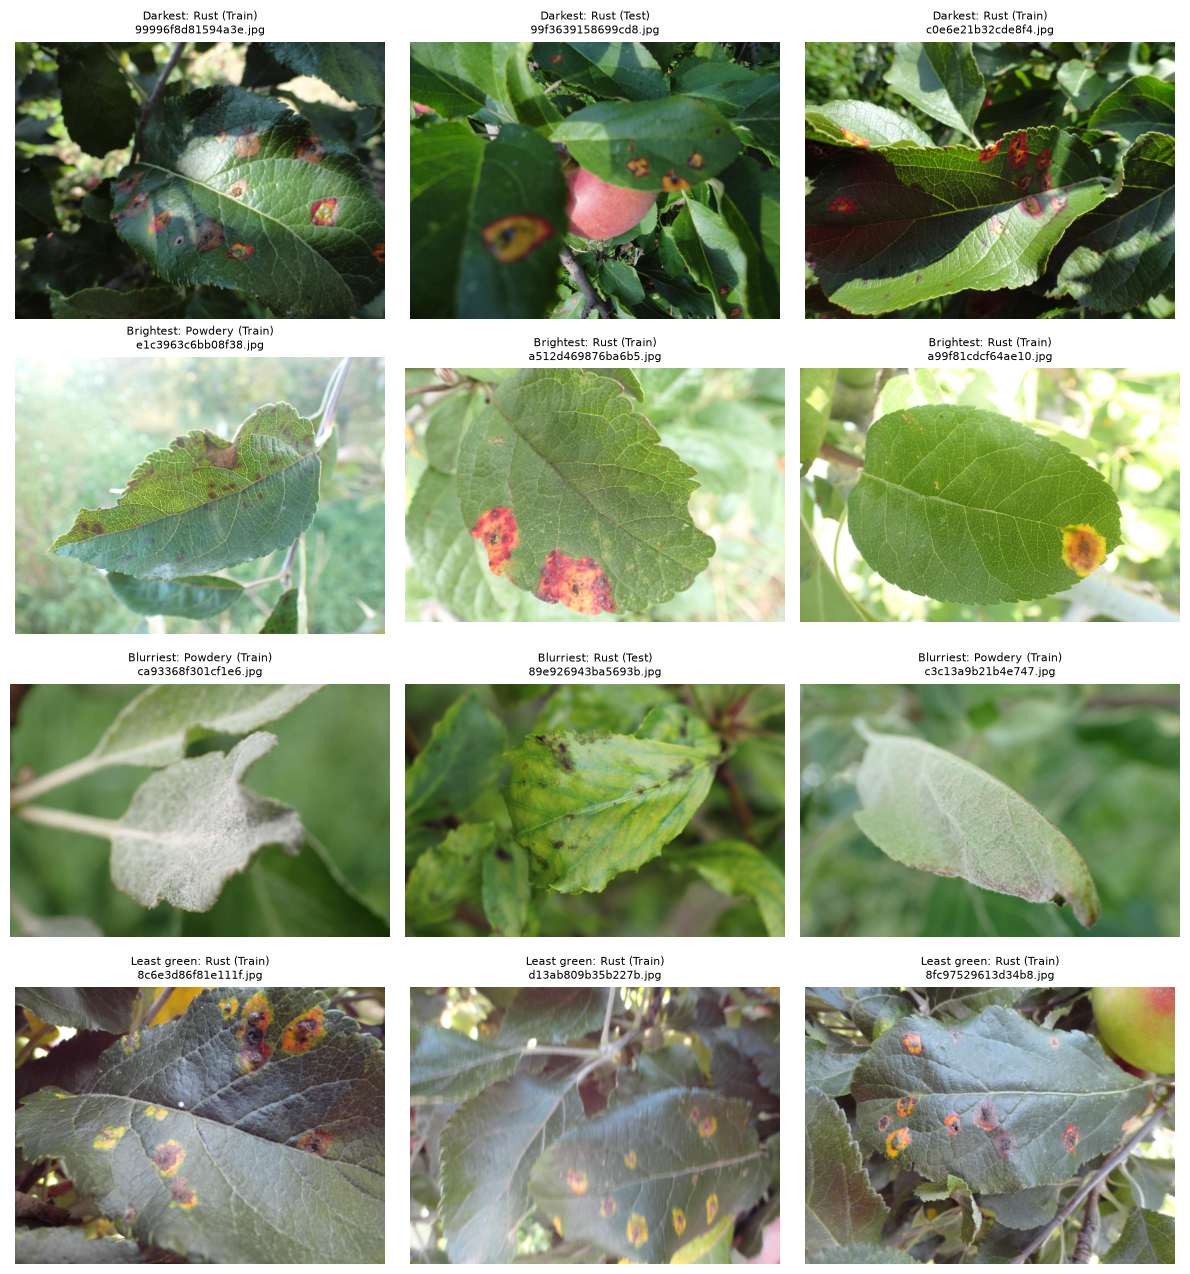

In [10]:
extremes = {"Darkest": df.nsmallest(3, "brightness"), "Brightest": df.nlargest(3, "brightness"),
            "Blurriest": df.nsmallest(3, "sharpness"), "Least green": df.nsmallest(3, "green_fraction")}
fig, axes = plt.subplots(len(extremes), 3, figsize=(12, 3.2 * len(extremes)))
for r, (name, rows) in enumerate(extremes.items()):
    for c, (_, row) in enumerate(rows.iterrows()):
        im = Image.open(row.path); im.draft("RGB", (600, 400))
        axes[r, c].imshow(im.convert("RGB")); axes[r, c].axis("off")
        axes[r, c].set_title(f"{name}: {row['class']} ({row.split})\n{row.filename}", fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "quality_extremes.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation.** The extremes are still valid, correctly labelled examples rather than defects: the darkest images are shaded Rust leaves, the brightest are backlit/over-exposed leaves, the least sharp are Powdery leaves with shallow depth of field (the Powdery coating itself reduces texture), and the 'least green' images are Rust leaves with dark, purple-tinged foliage. No image was removed. Note that one Test image (`89e926943ba5693b.jpg`, Rust) is among the three blurriest images in the whole dataset; it is also misclassified by MobileNetV2 (predicted Powdery), which links a data-quality issue to an observed model error. (The poster-like appearance of the thumbnails is a side effect of fast reduced-resolution JPEG decoding used only for this figure.)

## 6. Duplicate and near-duplicate detection (data-leakage check)
* **Exact duplicates:** identical MD5 hashes.
* **Near-duplicates:** 64-bit difference hash (dHash) with Hamming distance ≤ 6. dHash is robust to resizing and re-compression but not to large crops or rotations, so it is a *lower bound* on true near-duplicates.

Any duplicate that spans Train and Validation/Test would inflate validation/test scores for **every** model.

In [11]:
exact = df[df.duplicated("md5", keep=False)].sort_values("md5")
print("Files involved in exact duplicates:", len(exact))
display(exact[["split", "class", "filename", "md5"]])

hashes = np.array(df.dhash.astype(object).apply(int).tolist(), dtype=np.uint64)
bits = np.unpackbits(hashes.view(np.uint8).reshape(-1, 8), axis=1).astype(np.uint8)
dist = (bits[:, None, :] != bits[None, :, :]).sum(-1)
THRESH = 6
ii, jj = np.where(np.triu(dist <= THRESH, k=1))
pairs = pd.DataFrame({
    "file_a": df.filename.values[ii], "split_a": df.split.values[ii], "class_a": df["class"].values[ii],
    "file_b": df.filename.values[jj], "split_b": df.split.values[jj], "class_b": df["class"].values[jj],
    "hamming": dist[ii, jj], "exact": df.md5.values[ii] == df.md5.values[jj]})
pairs["cross_split"] = pairs.split_a != pairs.split_b
pairs["label_conflict"] = pairs.class_a != pairs.class_b
pairs.to_csv(RESULTS_DIR / "eda_duplicate_pairs.csv", index=False)
print(f"Near-duplicate pairs (Hamming <= {THRESH}):", len(pairs))
print("  cross-split pairs:", int(pairs.cross_split.sum()), "| label conflicts:", int(pairs.label_conflict.sum()))
display(pairs.groupby(["split_a", "split_b"]).size().rename("pairs").reset_index())

Files involved in exact duplicates: 0


,split,class,filename,md5


Near-duplicate pairs (Hamming <= 6): 2
  cross-split pairs: 0 | label conflicts: 0


,split_a,split_b,pairs
0,Train,Train,2


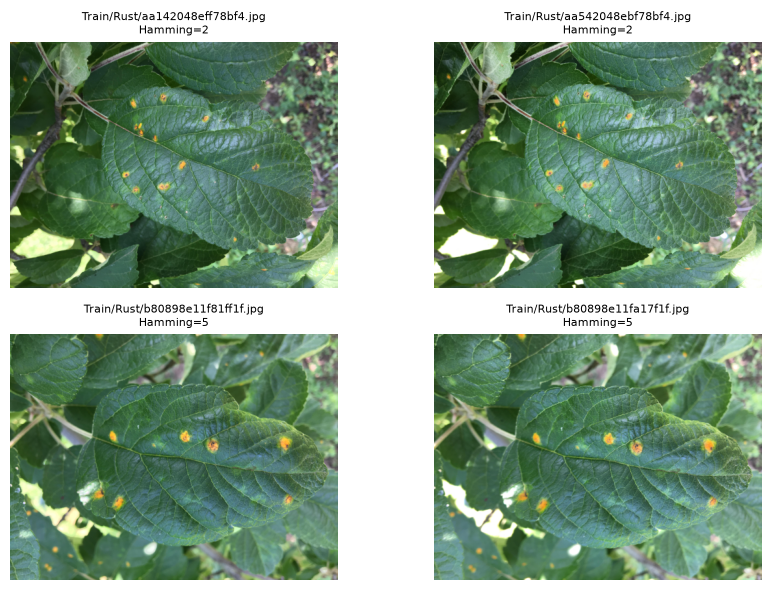

Test images with a Train near-duplicate: 0 of 150
Validation images with a Train near-duplicate: 0 of 60


In [12]:
def split_pair(a, b): return " / ".join(sorted([a, b]))
show = pairs.sort_values(["cross_split", "hamming"], ascending=[False, True]).head(6)
if len(show):
    fig, axes = plt.subplots(len(show), 2, figsize=(9, 3 * len(show)))
    axes = np.atleast_2d(axes)
    lookup = df.set_index(["split", "class", "filename"]).path
    for r, (_, p) in enumerate(show.iterrows()):
        for c, (s, cl, f) in enumerate([(p.split_a, p.class_a, p.file_a), (p.split_b, p.class_b, p.file_b)]):
            im = Image.open(lookup[(s, cl, f)]); im.draft("RGB", (500, 330))
            axes[r, c].imshow(im.convert("RGB")); axes[r, c].axis("off")
            axes[r, c].set_title(f"{s}/{cl}/{f}\nHamming={p.hamming}{' (exact)' if p.exact else ''}", fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / "near_duplicates.png", dpi=200, bbox_inches="tight"); plt.show()
else:
    print("No near-duplicate pairs found.")

# Which test images have a near-duplicate in Train? (reused by the model notebooks' error analysis)
test_leaks = pairs[(pairs.split_a == "Test") & (pairs.split_b == "Train") | (pairs.split_a == "Train") & (pairs.split_b == "Test")]
leaked_test_files = sorted(set(np.where(test_leaks.split_a == "Test", test_leaks.file_a, test_leaks.file_b)))
val_leaks = pairs[((pairs.split_a == "Validation") & (pairs.split_b == "Train")) | ((pairs.split_a == "Train") & (pairs.split_b == "Validation"))]
leaked_val_files = sorted(set(np.where(val_leaks.split_a == "Validation", val_leaks.file_a, val_leaks.file_b)))
print("Test images with a Train near-duplicate:", len(leaked_test_files), "of", (df.split == "Test").sum())
print("Validation images with a Train near-duplicate:", len(leaked_val_files), "of", (df.split == "Validation").sum())

**Interpretation.** There are **no exact duplicates** (identical MD5) and only **two near-duplicate pairs**, both inside **Train/Rust** (the same leaf photographed twice from a slightly different position; Hamming distance 2 and 5). **No near-duplicate crosses the Train/Validation/Test boundary** and no pair has conflicting labels, so there is **no detected train–test leakage** and the test results of all four models can be treated as genuinely unseen-data results. The two within-train pairs slightly over-weight two Rust leaves but are harmless and were kept. Caveat: dHash only detects near-identical framing, so different photographs of the same physical leaf or tree could still exist across splits; the creator does not document how the splits were formed.

## 7. Summary of findings

In [13]:
eda_summary = {
    "total_images": int(len(df)), "creator_stated_total": 1530,
    "per_split": df.split.value_counts()[SPLITS].to_dict(),
    "per_split_class": {s: df[df.split == s]["class"].value_counts()[CLASS_NAMES].to_dict() for s in SPLITS},
    "train_imbalance_ratio": round(float(train_counts.max() / train_counts.min()), 3),
    "corrupt_files": int((~df.readable).sum()),
    "formats": dict(Counter(df.format)), "modes": dict(Counter(df["mode"])),
    "distinct_resolutions": int(len(res)),
    "most_common_resolution": f"{res.iloc[0].width}x{res.iloc[0].height} ({res.iloc[0].images} images)",
    "median_megapixels": round(float(df.megapixels.median()), 2),
    "exact_duplicate_files": int(len(exact)),
    "near_duplicate_pairs": int(len(pairs)), "near_duplicate_threshold": THRESH,
    "cross_split_near_duplicate_pairs": int(pairs.cross_split.sum()),
    "label_conflict_pairs": int(pairs.label_conflict.sum()),
    "test_images_with_train_near_duplicate": len(leaked_test_files),
    "validation_images_with_train_near_duplicate": len(leaked_val_files),
    "leaked_test_files": leaked_test_files, "leaked_validation_files": leaked_val_files,
}
with open(RESULTS_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=4, default=int)
{k: v for k, v in eda_summary.items() if not k.startswith("leaked")}

{'total_images': 1532,
 'creator_stated_total': 1530,
 'per_split': {'Train': 1322, 'Validation': 60, 'Test': 150},
 'per_split_class': {'Train': {'Healthy': 458, 'Powdery': 430, 'Rust': 434},
  'Validation': {'Healthy': 20, 'Powdery': 20, 'Rust': 20},
  'Test': {'Healthy': 50, 'Powdery': 50, 'Rust': 50}},
 'train_imbalance_ratio': 1.065,
 'corrupt_files': 0,
 'formats': {'JPEG': 1532},
 'modes': {'RGB': 1532},
 'distinct_resolutions': 8,
 'most_common_resolution': '4000x2672 (1130 images)',
 'median_megapixels': 10.69,
 'exact_duplicate_files': 0,
 'near_duplicate_pairs': 2,
 'near_duplicate_threshold': 6,
 'cross_split_near_duplicate_pairs': 0,
 'label_conflict_pairs': 0,
 'test_images_with_train_near_duplicate': 0,
 'validation_images_with_train_near_duplicate': 0}

### Key EDA findings and their consequences
| Finding | Evidence | Consequence for the project |
|---|---|---|
| Source verified | Kaggle, Rashik Rahman, CC0-1.0, v1 (2021-07-04) | Free to use; cite creator and URL in the report |
| 1,532 images (creator states 1,530) | File inventory | Discrepancy documented, data unchanged |
| Nearly balanced classes | Train ratio 1.065; Val/Test exactly balanced | Accuracy meaningful; no class weighting needed |
| Tiny validation split (60) | 3.9% of data | Validation accuracy saturates; use validation loss for selection; limitation discussed |
| 0 corrupt files, all RGB JPEG, no EXIF rotation | Full decode check | No cleaning step required |
| Very high resolution, ~1.5:1 aspect | Median 10.7 MP | Resize to 224×224 distorts aspect and loses fine lesion detail — identical for all models |
| Classes differ in colour/brightness | Powdery brighter/bluer; Rust less green | Colour is diagnostic → no hue augmentation; check models are not using only global colour (Grad-CAM) |
| No covariate shift between splits | Matched statistics | Test set is a fair in-distribution estimate |
| No cross-split duplicates | MD5 + dHash | No detected leakage; 2 harmless within-train near-duplicates |
| In-field images with cluttered backgrounds | Visual inspection | Background/lighting are plausible error sources; motivates augmentation and error analysis |